In [3]:
import numpy as np
import pandas as pd
np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

In [5]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [6]:

import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))


In [8]:

# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])


In [9]:

# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [12]:

# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [13]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [14]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

Mean Vector:
[0.43372142 0.46078965 0.66767044]

Covariance Matrix:
[[1.34076734 0.24528825 0.10420627]
 [0.24528825 1.12566959 0.23643388]
 [0.10420627 0.23643388 1.327287  ]]

Eigenvalues:
[1.65691289 1.22963722 0.90717381]

Eigenvectors:
[[-0.61002583 -0.69239396  0.3853039 ]
 [-0.53982115  0.00718615 -0.84174906]
 [-0.58005311  0.72148387  0.37815264]]


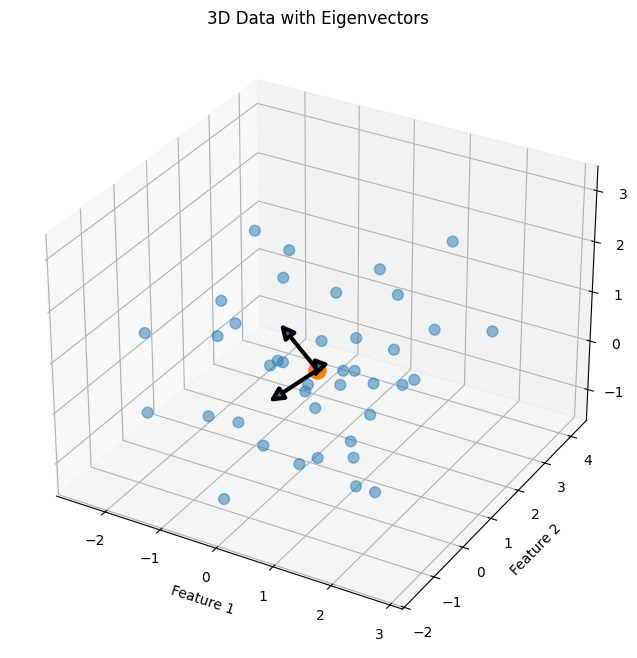

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


# =========================================================
# 1. Generate Class 1 Data
# =========================================================

np.random.seed(23)

mu_vec1 = np.array([0, 0, 0])

cov_mat1 = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])

class1_sample = np.random.multivariate_normal(
    mu_vec1,
    cov_mat1,
    20
)

df = pd.DataFrame(
    class1_sample,
    columns=['feature1', 'feature2', 'feature3']
)

df['target'] = 1


# =========================================================
# 2. Generate Class 2 Data
# =========================================================

mu_vec2 = np.array([1, 1, 1])

cov_mat2 = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])

class2_sample = np.random.multivariate_normal(
    mu_vec2,
    cov_mat2,
    20
)

df1 = pd.DataFrame(
    class2_sample,
    columns=['feature1', 'feature2', 'feature3']
)

df1['target'] = 0


# =========================================================
# 3. Combine Both DataFrames
# =========================================================

df = pd.concat(
    [df, df1],
    ignore_index=True
)

# Shuffle data
df = df.sample(
    frac=1,
    random_state=23
).reset_index(drop=True)


# =========================================================
# 4. Calculate Mean
# =========================================================

mean_vector = df[
    ['feature1', 'feature2', 'feature3']
].mean().values

print("Mean Vector:")
print(mean_vector)


# =========================================================
# 5. Calculate Covariance Matrix
# =========================================================

cov_matrix = np.cov(
    df[['feature1', 'feature2', 'feature3']].T
)

print("\nCovariance Matrix:")
print(cov_matrix)


# =========================================================
# 6. Calculate Eigenvalues and Eigenvectors
# =========================================================

eigen_values, eigen_vectors = np.linalg.eig(
    cov_matrix
)

print("\nEigenvalues:")
print(eigen_values)

print("\nEigenvectors:")
print(eigen_vectors)


# =========================================================
# 7. Arrow3D Class
# =========================================================

class Arrow3D(FancyArrowPatch):

    def __init__(self, xs, ys, zs, *args, **kwargs):

        FancyArrowPatch.__init__(
            self,
            (0, 0),
            (0, 0),
            *args,
            **kwargs
        )

        self._verts3d = xs, ys, zs


    def draw(self, renderer):

        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d,
            ys3d,
            zs3d,
            self.axes.get_proj()
        )

        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )

        FancyArrowPatch.draw(
            self,
            renderer
        )


    def do_3d_projection(self):

        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d,
            ys3d,
            zs3d,
            self.axes.get_proj()
        )

        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )

        return np.min(zs)


# =========================================================
# 8. Create 3D Plot
# =========================================================

fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(
    111,
    projection='3d'
)


# =========================================================
# 9. Plot Data Points
# =========================================================

ax.scatter(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    s=60,
    alpha=0.5
)


# =========================================================
# 10. Plot Mean Point
# =========================================================

ax.scatter(
    mean_vector[0],
    mean_vector[1],
    mean_vector[2],
    s=150,
    marker='o',
    alpha=1
)


# =========================================================
# 11. Plot Eigenvectors
# =========================================================

for v in eigen_vectors.T:

    arrow = Arrow3D(
        [
            mean_vector[0],
            mean_vector[0] + v[0]
        ],

        [
            mean_vector[1],
            mean_vector[1] + v[1]
        ],

        [
            mean_vector[2],
            mean_vector[2] + v[2]
        ],

        mutation_scale=20,
        lw=3,
        arrowstyle="-|>"
    )

    ax.add_artist(arrow)


# =========================================================
# 12. Labels
# =========================================================

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')

ax.set_title('3D Data with Eigenvectors')


# =========================================================
# 13. Show Plot
# =========================================================

plt.show()

In [19]:

pc = eigen_vectors[0:2]
pc

array([[-0.61002583, -0.69239396,  0.3853039 ],
       [-0.53982115,  0.00718615, -0.84174906]])

In [20]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,1.571096,-0.353855,1
1,-0.714905,-2.494424,0
2,0.459927,-0.022297,1
3,-3.953371,-0.807297,0
4,-0.475664,-3.746533,0


In [21]:

new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()